<a href="https://colab.research.google.com/github/ajitesh68/machine-learning-practice-/blob/main/TF002_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INRODUCTION TO REGRESSION WITH NEURAL NETWORKS


there are many definition for a regression prblm but in our case we are going other combination of variables , even shorter .... predicting a number

In [ ]:
#IMPORT tensorflow
import tensorflow as tf
print(tf.__version__)

2.18.0


Creating data to view and fit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#crate features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0], dtype=float)

#create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0], dtype=float)

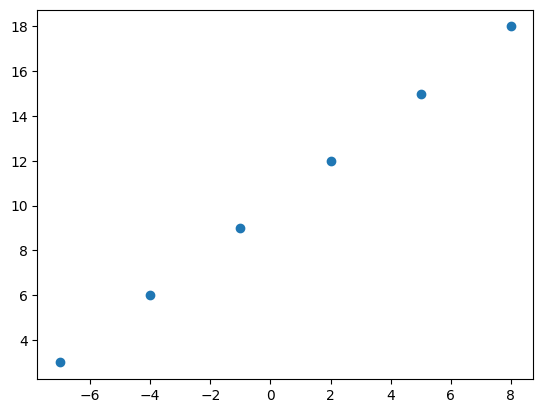

In [ ]:
plt.scatter(x,y)

In [ ]:
y == x+10

array([ True,  True,  True,  True,  True,  True])

Input and Output shapes

In [ ]:
#create a demo tensor for our houseing prediction problem
house_info = tf.constant(["bedroom","bathroom","garage"])
house_price = tf.constant([939700])

In [ ]:
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [ ]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [ ]:
x[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [ ]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [ ]:
x[0].ndim

0

In [ ]:
x[0] , y[0]

(np.float64(-7.0), np.float64(3.0))

In [ ]:
#convert numpy arrays into tensors with dtype float 32
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)

In [ ]:
x , y


(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [ ]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape
#there is no shape as there is single value or scalar value

(TensorShape([]), TensorShape([]))

Steps in creating a model with TensorFlow

1. Creating a model - define the i/p and o/p layers , as well as the hidden layers of a deep learning model

2. Comppiling a model - define a loss fnc (in other words, the fnc which tells our model how wrong our model how wrong it is ) and optimizer (tells our model how to improve the patterns its learning ) and evaluation metrics (what we can use to interpret the performance of our model).

3. Fitting a model- letting the model try to find patterns between x & y (features and labels)

In [ ]:
#Set random seed
tf.random.set_seed

#1. create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])# mae are short for mean absolute error
              #sgd is short for stochastic gradient descent

#3. Fit the model
model.fit(tf.expand_dims(x, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step - loss: 11.8047 - mae: 11.8047
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 11.7200 - mae: 11.7200
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.6353 - mae: 11.6353
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 11.5506 - mae: 11.5506
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 11.4659 - mae: 11.4659


In [ ]:
#check out x and y
x , y

(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [ ]:
#Try add make prediction using our model
import numpy as np

y_pred = model.predict(np.array([[17.0]]))  # double brackets to make it 2D
print(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[[-11.386772]]


In [ ]:
y_pred + 10   # mae: 9.8731 hence we our adding 10 to y predicted

array([[-1.3867722]], dtype=float32)

Improving our model

Steps we can improve our model, by altering the steps we took to create a model

1. Create a model -- here we might add more layersm increase the number of hidden units (all called neurons) within each of the hidden layers , change the activation fnc of each layer

2. "Compiling a model" -- here we might change the optimization fnc or perhaps the "learning rate" of the optimization fnc

3. "Fitting a model" -- here we might fit a model for more ""epochs"" (leave it training for longer) or on more data (give the model more example to learn from).

In [ ]:
#higher the learning rate the more model pushes to improve at every step and lower the learning rate
# the model take lower steps to improve the model

In [ ]:
import numpy as np

# If x was like this:
# x = [1.0, 2.0, 3.0, 4.0]

# Do this instead:
x = np.array([[1.0], [2.0], [3.0], [4.0]])
y = np.array([2.0, 4.0, 6.0, 8.0])  # keep y as 1D


In [ ]:
#Lets rebuild our model

#1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

#3. Fit the model
model.fit(x, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - loss: 2.6694 - mae: 2.6694
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2.5969 - mae: 2.5969
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.5244 - mae: 2.5244
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.4519 - mae: 2.4519
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 2.3794 - mae: 2.3794
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.3069 - mae: 2.3069
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 2.2344 - mae: 2.2344
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 2.1619 - mae: 2.1619
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.0894 - mae: 2.0894
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.0169 - mae: 2.0169
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1.9444 - mae: 1.9444
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.8719 - mae: 1.8719
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/st

In [ ]:
#Remind ourselves of the data
x,y


(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [ ]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[33.188293]], dtype=float32)

In [ ]:
#Let's see if we can make another to improve our model

#create the model (this time with an extra hidden layer with 100 hidden units)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(50,activation= None),
    tf.keras.layers.Dense(1)
])

#2 . Compile the model
model.compile(loss ="mae",
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["mae"])


#fit the model
model.fit(x,y,epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 6.3018 - mae: 6.3018
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 6.2492 - mae: 6.2492
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 6.1966 - mae: 6.1966
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 6.1440 - mae: 6.1440
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 6.0915 - mae: 6.0915
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 6.0391 - mae: 6.0391
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 5.9867 - mae: 5.9867
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 5.9344 - mae: 5.9344
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 5.8821 - mae: 5.8821
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 5.8300 - mae: 5.8300
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 5.7778 - mae: 5.7778
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 5.7257 - mae: 5.7257
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143m

In [ ]:
#Remind ourselves of the data
x,y

(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [ ]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([[22.616163]], dtype=float32)

Common Ways To Improve the Deep Model

1. Adding The Layers
2. Increase the number of hidden units
3. Change the activation fnc
4. Change the optimization fnc
5. Change the learning rate(potentially the most imp hyperparameter of many diff neural networks)
6. Fitting more data
7. Fitting for longer



Evaluating a Model

In practice, a typical workflow you will go through while building a neural networks is:

Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it....

When it comes to evaluation.... there are 3 words you should memorize:

"Visualize, Visualize , Visualize"

It's good idea to visualize:

* the data we are working with? What does it look like ?
* The model itself - What does our model look like?
* The training of a model how does a model perform while learn
* The prediction of a model how does a prediction of a model line up against the ground truth ( the original labels)?

In [ ]:
#Make a bigger dataset  most probably for a good prediction or training

x  = tf.range(-100,100,4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [ ]:
#we want our model to learn this formula
y = x + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

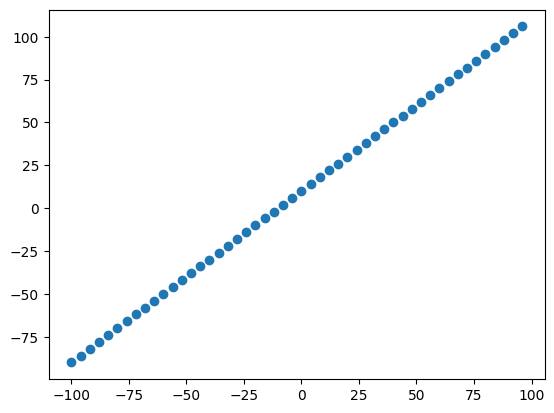

In [ ]:
#visulaize our data
import matplotlib.pyplot as plt
plt.scatter(x,y)


# There are 3 sets ..........

**Training set** :- The model learn from this data , typically contains 80% of the the total dataset available

**Validation dataset** :- The model gets tuned on this data , typically contains 10%-15% of the the total dataset available

**Testing dataset** :- The model gets test on this data , typically contains 10%-15% of the the total dataset available

In [ ]:
len(x)

50

In [ ]:
#Split the data into training and testing dataset

x_train = x[:40]#80% of the data is been given for training from 1-40     #first 40 are training samples
x_test = x[40:]#20% of the data is been given for testing from 41-50

y_train = x[:40]
y_test = x[40:]

In [ ]:
len(x_test), len(x_train), len(y_test), len(y_train)

(10, 40, 10, 40)

**Visualizing the predictions**
Now we've got a trained model, let's visualize some predictions.

To visualize predictions, it's always a good idea to plot them against the ground truth labels.

Often you'll see this in the form of y_test vs. y_pred (ground truth vs. predictions).

First, we'll make some predictions on the test data (X_test), remember the model has never seen the test data.

In [ ]:
# Make predictions
y_preds = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [ ]:

# View the predictions
y_preds

array([[ 77.18708 ],
       [ 82.26345 ],
       [ 87.339806],
       [ 92.416176],
       [ 97.49254 ],
       [102.5689  ],
       [107.64526 ],
       [112.72164 ],
       [117.798004],
       [122.87436 ]], dtype=float32)

In [ ]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=y_preds):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

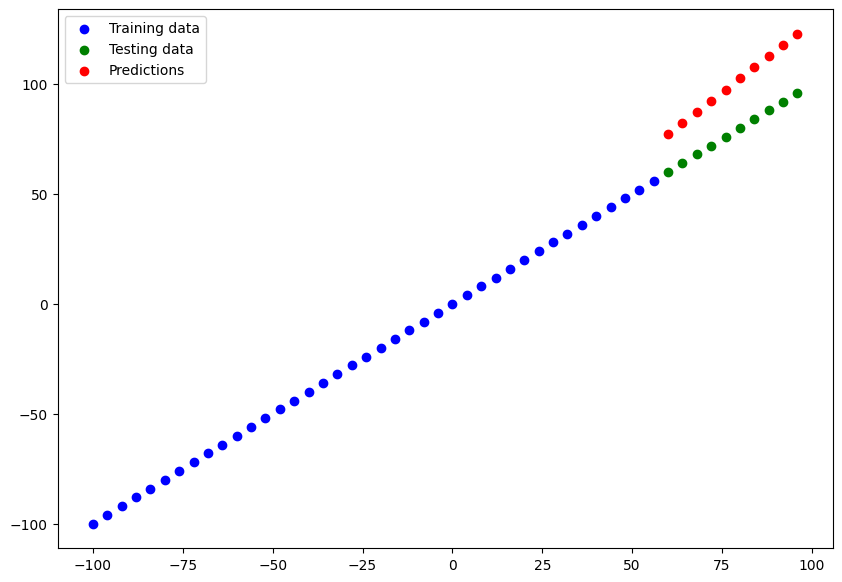

In [ ]:
plot_predictions(train_data=x_train,
                 train_labels=y_train,
                 test_data=x_test,
                 test_labels=y_test,
                 predictions=y_preds)

In [ ]:
def mae(y_test, y_pred):
  """
  Calculuates mean absolute error between y_test and y_preds.
  """
  return tf.metrics.MAE(y_test,y_pred)

def mse(y_test, y_pred):
  """
  Calculates mean squared error between y_test and y_preds.
  """
  return tf.metrics.MSE(y_test,y_pred)

**Running experiments to improve a model**

After seeing the evaluation metrics and the predictions your model makes, it's likely you'll want to improve it.

Again, there are many different ways you can do this, but 3 of the main ones are:

**Get more data** - get more examples for your model to train on (more opportunities to learn patterns).

**Make your model larger (use a more complex model)** - this might come in the form of more layers or more hidden units in each layer.

**Train for longer** - give your model more of a chance to find the patterns in the data.

Since we created our dataset, we could easily make more data but this isn't always the case when you're working with real-world datasets.

So let's take a look at how we can improve our model using 2 and 3.

To do so, we'll build 3 models and compare their results:

model_1 - same as original model, 1 layer, trained for 100 epochs.
model_2 - 2 layers, trained for 100 epochs.
model_3 - 2 layers, trained for 500 epochs.
**Build model_1**

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Replicate original model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_1.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 41.1203 - mae: 41.1203 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8.1073 - mae: 8.1073
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6.0271 - mae: 6.0271
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.9469 - mae: 3.9469
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.6178 - mae: 2.6178
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.9470 - mae: 3.9470
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.6177 - mae: 2.6177
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.9471 - mae: 3.9471
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.6175 - mae: 2.6175
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.9472 - mae: 3.9472
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.6174 - mae: 2.6174 
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.9473 - mae: 3.9473
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


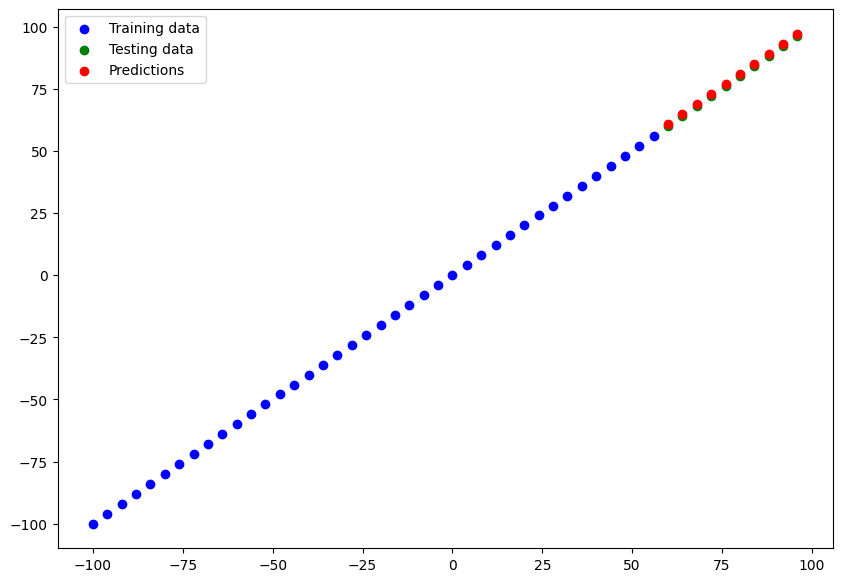

In [ ]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(x_test)
plot_predictions(predictions=y_preds_1)

In [ ]:
tf.constant(y_preds_1) , tf.squeeze(y_preds_1)

#squeeze reduce the dimension by 1

(<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
 array([[60.67474 ],
        [64.71974 ],
        [68.76475 ],
        [72.809746],
        [76.85475 ],
        [80.89976 ],
        [84.944756],
        [88.98976 ],
        [93.03477 ],
        [97.079765]], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([60.67474 , 64.71974 , 68.76475 , 72.809746, 76.85475 , 80.89976 ,
        84.944756, 88.98976 , 93.03477 , 97.079765], dtype=float32)>)

In [ ]:

# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(np.float32(0.87725335), np.float32(0.78628194))

In [ ]:
# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1).numpy()
mse_1 = mse(y_test, y_preds_1).numpy()
mae_1, mse_1

(array([0.67473984, 0.7197418 , 0.7647476 , 0.8097458 , 0.8547516 ,
        0.8997574 , 0.94475555, 0.98976135, 1.0347672 , 1.0797653 ],
       dtype=float32),
 array([0.45527384, 0.5180283 , 0.5848389 , 0.6556882 , 0.7306003 ,
        0.80956334, 0.89256305, 0.97962755, 1.0707431 , 1.1658932 ],
       dtype=float32))

**model_2 **

In [ ]:
tf.random.set_seed(42)

#build the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
]
)

#compile the model

model_2.compile(loss=tf.keras.losses.mae,
                metrics=["mse"],
                optimizer=tf.keras.optimizers.SGD())

#fit the model
# model_2.fit(tf.expand_dims(x_train, axis=-1), y_train , epochs=100)

x_train = tf.reshape(x_train, (-1, 1))  # Reshape (40,) → (40, 1)
model_2.fit(x_train, y_train, epochs=100)
# Your model expects input with an extra dimension (e.g., (batch, timesteps, channels)), but x_train is missing it
# Working Code: tf.expand_dims(x_train, axis=-1) adds the missing dimension (e.g., from (1000, 10) to (1000, 10, 1)).

#(Example: If your first layer is Conv1D, it needs 3D input—so your fix is correct!)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 81.0206 - mse: 10155.8066 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 58.9377 - mse: 5031.2534
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 20.0810 - mse: 625.0889
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 12.2642 - mse: 352.4775
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 15.4387 - mse: 345.6694
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 18.3991 - mse: 484.7449
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 21.1555 - mse: 700.3716
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 36.3062 - mse: 1896.7650
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.8870 - mse: 170.1591
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 14.9026 - mse: 311.2525
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 18.5648 - mse: 515.8160
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 22.6814 - mse: 772.9818
Epoch 13/

In [ ]:
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
x_train.shape

TensorShape([40, 1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


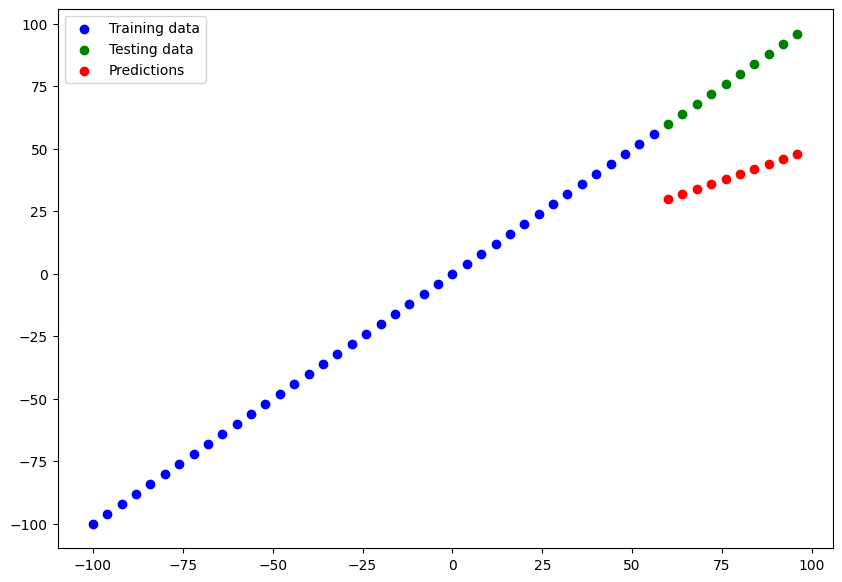

In [ ]:
y_preds_2 = model_2.predict(x_test)
plot_predictions(predictions=y_preds_2)

#red dots should be plot close to the green dots in order to claim a better model

In [ ]:
# Calculate model_2 metrics
mae_2 = mae(y_test, y_preds_2)
mse_2 = mse(y_test, y_preds_2)
mae_2, mse_2

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([29.956827, 31.951366, 33.9459  , 35.940437, 37.93497 , 39.929504,
        41.92404 , 43.91858 , 45.913116, 47.907646], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 897.4115 , 1020.88983, 1152.3241 , 1291.7151 , 1439.062  ,
        1594.3654 , 1757.6252 , 1928.8416 , 2108.0142 , 2295.1426 ],
       dtype=float32)>)

Model_3

 2 layers and 500 epochs

In [ ]:
tf.random.set_seed(42)

#build the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
]
)

#compile the model

model_3.compile(loss=tf.keras.losses.mae,
                metrics=["mae"],
                optimizer=tf.keras.optimizers.SGD())

#fit the model
# model_2.fit(tf.expand_dims(x_train, axis=-1), y_train , epochs=100)

x_train = tf.reshape(x_train, (-1, 1))  # Reshape (40,) → (40, 1)
model_3.fit(x_train, y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 73.5016 - mae: 73.5016 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 52.4342 - mae: 52.4342
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 42.0515 - mae: 42.0515
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 39.7671 - mae: 39.7671
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.5425 - mae: 9.5425
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 15.0837 - mae: 15.0837 
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 18.3777 - mae: 18.3777 
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 21.6959 - mae: 21.6959
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 33.3044 - mae: 33.3044
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 6.1186 - mae: 6.1186 
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 15.6746 - mae: 15.6746 
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 19.1894 - mae: 19.1894 
Epoch 13/500
2/2 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


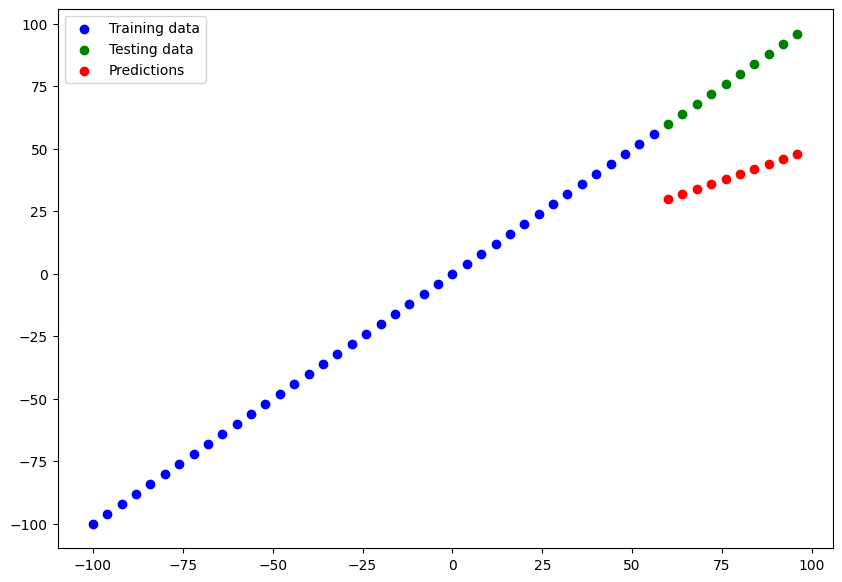

In [ ]:
y_preds_3 = model_3.predict(x_test)
plot_predictions(predictions=y_preds_3)

In [ ]:
# Calculate model_2 metrics
mae_3 = mae(y_test, y_preds_3)
mse_3 = mse(y_test, y_preds_3)
mae_3, mse_3

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([30.133347, 32.134148, 34.134945, 36.135746, 38.136543, 40.137344,
        42.13814 , 44.138947, 46.139736, 48.140545], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 908.01855, 1032.6034 , 1165.1945 , 1305.7921 , 1454.3959 ,
        1611.0065 , 1775.6229 , 1948.2466 , 2128.8752 , 2317.512  ],
       dtype=float32)>)

**Comparing results**

Now we've got results for 3 similar but slightly different results, let's compare them

In [ ]:
import tensorflow as tf

def to_numpy_compatible(value):
    # Convert input to TensorFlow tensor first
    tensor_value = tf.convert_to_tensor(value)
    # Now safely call .numpy()
    return tensor_value.numpy()

model_results = [
    ["model_1", to_numpy_compatible(mae_1), to_numpy_compatible(mse_1)],
    ["model_2", to_numpy_compatible(mae_2), to_numpy_compatible(mse_2)],
    ["model_3", to_numpy_compatible(mae_3), to_numpy_compatible(mse_3)]
]

In [ ]:
import pandas as pd
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results


,model,mae,mse
0,model_1,"[0.67473984, 0.7197418, 0.7647476, 0.8097458, ...","[0.45527384, 0.5180283, 0.5848389, 0.6556882, ..."
1,model_2,"[29.956827, 31.951366, 33.9459, 35.940437, 37....","[897.4115, 1020.88983, 1152.3241, 1291.7151, 1..."
2,model_3,"[30.133347, 32.134148, 34.134945, 36.135746, 3...","[908.01855, 1032.6034, 1165.1945, 1305.7921, 1..."


🔑 Note: One of your main goals should be to minimize the time between your experiments. The more experiments you do, the more things you'll figure out which don't work and in turn, get closer to figuring out what does work. Remember the machine learning practitioner's motto: "experiment, experiment, experiment".


**Saving a model**

Once you've trained a model and found one which performs to your liking, you'll probably want to save it for use elsewhere (like a web application or mobile device).

You can save a TensorFlow/Keras model using model.save().

There are two ways to save a model in TensorFlow:

**The SavedModel format (default).**
**The HDF5 format**.

The main difference between the two is the SavedModel is automatically able to save custom objects (such as special layers) without additional modifications when loading the model back in.

Which one should you use?

It depends on your situation but the SavedModel format will suffice most of the time.

Both methods use the same method call.

In [ ]:
model_1.save('best_model.keras')  # Native Keras format (lightweight)

In [ ]:

# Check it out - outputs a protobuf binary file (.pb) as well as other files
!ls best_model.keras

best_model.keras


Now saving a model using hdf5 format

In [ ]:

# Save a model using the HDF5 format
model_2.save("best_model_HDF5_format.h5") # note the addition of '.h5' on the end

In [ ]:
# Check it out
!ls best_model_HDF5_format.h5

best_model_HDF5_format.h5


**Loading a model**


We can load a saved model using the load_model() method.

Loading a model for the different formats (SavedModel and HDF5) is the same (as long as the pathnames to the particular formats are correct

In [ ]:
# Load a model from the SavedModel format
loaded_saved_model = tf.keras.models.load_model("best_model.keras")
loaded_saved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
model_1_preds = model_1.predict(x_test)
loaded_saved_model_preds = loaded_saved_model.predict(x_test)
model_1_preds == loaded_saved_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

How to download your file from google colab

In [ ]:
# Download the model (or any file) from Google Colab
from google.colab import files
files.download("best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**A larger example**


Alright, we've seen the fundamentals of building neural network regression models in TensorFlow.

Let's step it up a notch and build a model for a more feature rich dataset.

More specifically we're going to try predict the cost of medical insurance for individuals based on a number of different parameters such as, age, sex, bmi, children, smoking_status and residential_region.

To do, we'll leverage the pubically available Medical Cost dataset available from Kaggle and hosted on GitHub.

🔑 Note: When learning machine learning paradigms, you'll often go through a series of foundational techniques and then practice them by working with open-source datasets and examples. Just as we're doing now, learn foundations, put them to work with different problems. Every time you work on something new, it's a good idea to search for something like "problem X example with Python/TensorFlow" where you substitute X for your problem.

In [ ]:
import tensorflow as tf
import pandas as pd

import matplotlib.pyplot as plt


In [ ]:


# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [ ]:

# Check out the insurance dataset
insurance.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


We're going to have to turn the non-numerical columns into numbers (because a neural network can't handle non-numerical inputs).

To do so, we'll use the get_dummies() method in pandas.

It converts categorical variables (like the sex, smoker and region columns) into numerical variables using one-hot encoding.

In [ ]:
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [ ]:
# Replace True with 1 and False with 0
insurance_one_hot = insurance_one_hot.replace({True: 1, False: 0})

/tmp/ipython-input-91-3517674497.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_one_hot = insurance_one_hot.replace({True: 1, False: 0})


In [ ]:
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [ ]:
x = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [ ]:
y.head()


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [ ]:
x.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

len(x_train), len(x_test), len(x)

(1070, 268, 1338)

In [ ]:
x_train

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
737,26,23.700,2,False,True,True,False,False,False,False,True
369,18,30.400,3,False,True,True,False,True,False,False,False
284,52,31.200,0,True,False,True,False,False,False,False,True
1302,25,20.800,1,True,False,True,False,False,False,False,True
958,43,34.960,1,False,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1330,57,25.740,2,True,False,True,False,False,False,True,False
1016,19,24.605,1,True,False,True,False,False,True,False,False
165,47,28.215,4,False,True,True,False,True,False,False,False
7,37,27.740,3,True,False,True,False,False,True,False,False


In [ ]:
#build a neural network (sort of like model_2)
tf.random.set_seed(42)

#create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#compile the model
insurance_model.compile(loss=tf.keras.losses.mae,
                         optimizer=tf.keras.optimizers.SGD(),
                         metrics=["mae"])

#fit the model
insurance_model.fit(x_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9731.5146 - mae: 9731.5146  
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7389.9365 - mae: 7389.9365
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7531.0947 - mae: 7531.0947
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7602.9219 - mae: 7602.9219
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7586.7793 - mae: 7586.7793
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7450.0469 - mae: 7450.0469
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7563.0444 - mae: 7563.0444
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7532.1597 - mae: 7532.1597
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7494.1616 - mae: 7494.1616
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7559.1147 - mae: 7559.1147
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7511.8174 - mae: 7511.8174
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [ ]:
insurance_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133 (536.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)